# 2B Descriptores de textura

2.1 Local Binary Patterns (LBP)
2.2 Gray Level Co-occurrence Matrix (GLCM)
2.3 Filtros de Gabor

In [ ]:
!pip install scikit-image --quiet
!pip install -q kaggle
!pip install -U numpy scikit-image

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure
from glob import glob
import shutil
from tqdm import tqdm
import random
from PIL import Image
import seaborn as sns
import tensorflow as tf
import csv
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.feature import graycomatrix, graycoprops

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped"
train_normal = glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))
train_pneu   = glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg"))

test_normal = glob(os.path.join(DATASET_PATH, "test/NORMAL/*.jpeg"))
test_pneu   = glob(os.path.join(DATASET_PATH, "test/PNEUMONIA/*.jpeg"))

val_normal = glob(os.path.join(DATASET_PATH, "val/NORMAL/*.jpeg"))
val_pneu   = glob(os.path.join(DATASET_PATH, "val/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal))
print("PNEUMONIA train:", len(train_pneu))

print("NORMAL test:", len(test_normal))
print("PNEUMONIA test:", len(test_pneu))

print("NORMAL val:", len(val_normal))
print("PNEUMONIA val:", len(val_pneu))

NORMAL train: 1341
PNEUMONIA train: 3875
NORMAL test: 234
PNEUMONIA test: 390
NORMAL val: 8
PNEUMONIA val: 8


#2.1. Local Binary Patterns (LBP)


Imagen: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped/train/NORMAL/NORMAL2-IM-0592-0001.jpeg
Dimensión total del vector LBP: 54
  LBP(P=8, R=1):
    Histograma: [0.0244751  0.02928162 0.0284729  0.05114746 0.07733154 0.05702209
 0.03125    0.02540588 0.6304474  0.04516602]
  LBP(P=16, R=2):
    Histograma: [0.02095032 0.01330566 0.01365662 0.01228333 0.01303101 0.01551819
 0.01795959 0.02615356 0.03425598 0.02928162 0.02006531 0.01625061
 0.01332092 0.0118103  0.01049805 0.00987244 0.62327576 0.09851074]
  LBP(P=24, R=3):
    Histograma: [0.01791382 0.00953674 0.00917053 0.00700378 0.00759888 0.00735474
 0.00727844 0.00817871 0.00924683 0.01113892 0.01306152 0.01580811
 0.01959229 0.01832581 0.01307678 0.01126099 0.00941467 0.00772095
 0.00759888 0.00727844 0.00674438 0.00637817 0.00611877 0.00570679
 0.6199646  0.13752747]

Imagen: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped/train/

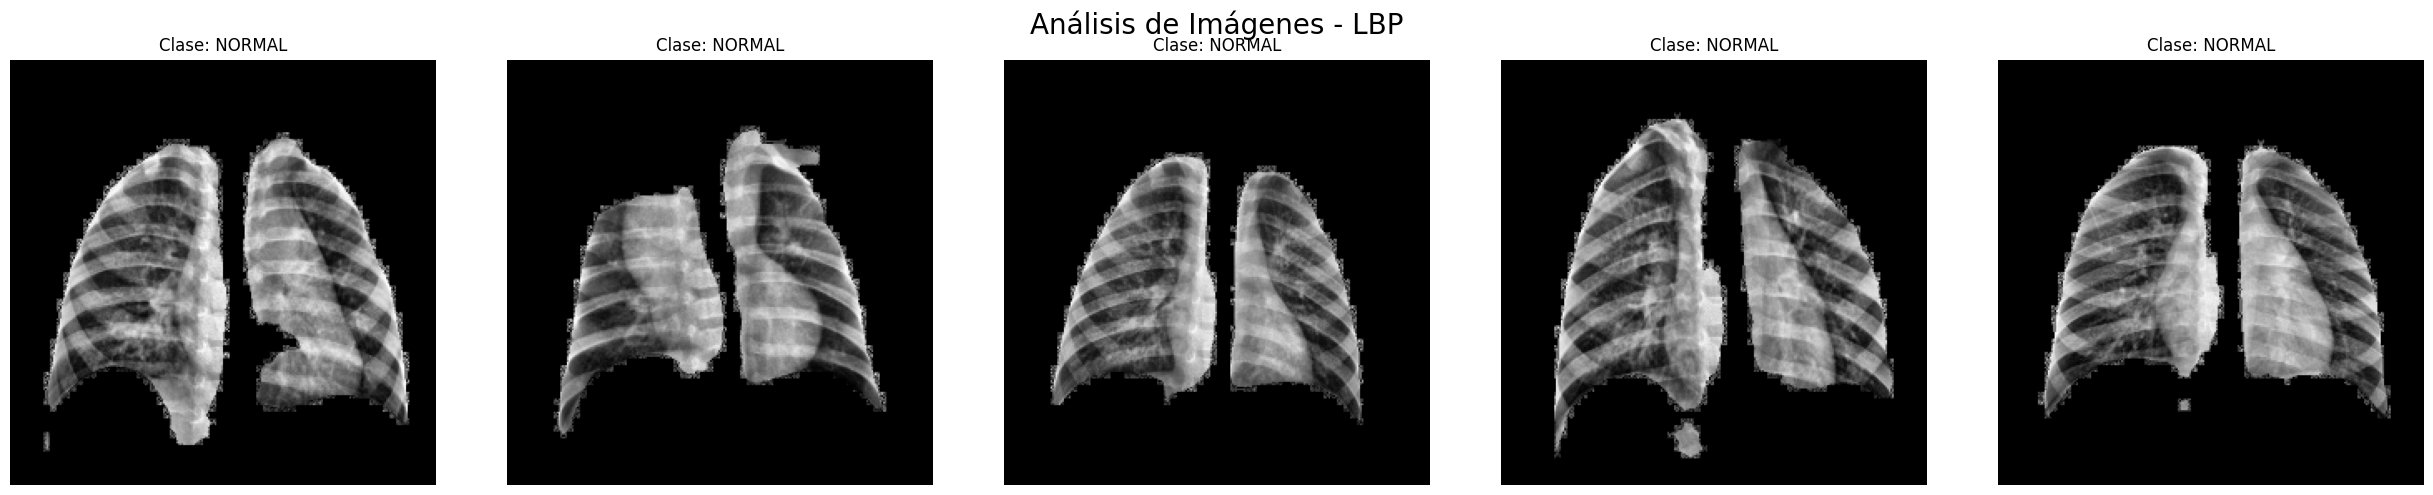


Imagen: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped/train/PNEUMONIA/person62_bacteria_301.jpeg
Dimensión total del vector LBP: 54
  LBP(P=8, R=1):
    Histograma: [0.02844238 0.03338623 0.02770996 0.05064392 0.08143616 0.06018066
 0.03337097 0.03025818 0.5996094  0.05496216]
  LBP(P=16, R=2):
    Histograma: [0.02207947 0.01554871 0.0135498  0.01174927 0.01225281 0.01457214
 0.01823425 0.02861023 0.0431366  0.03419495 0.02174377 0.01725769
 0.01512146 0.01237488 0.01123047 0.01127625 0.58625793 0.11080933]
  LBP(P=24, R=3):
    Histograma: [0.01730347 0.00987244 0.00906372 0.00810242 0.00701904 0.00614929
 0.00730896 0.00872803 0.01062012 0.01145935 0.0141449  0.02046204
 0.02728271 0.02357483 0.01568604 0.01403809 0.01022339 0.0091095
 0.00862122 0.00817871 0.00730896 0.00630188 0.00602722 0.00563049
 0.5817108  0.14607239]

Imagen: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped/tra

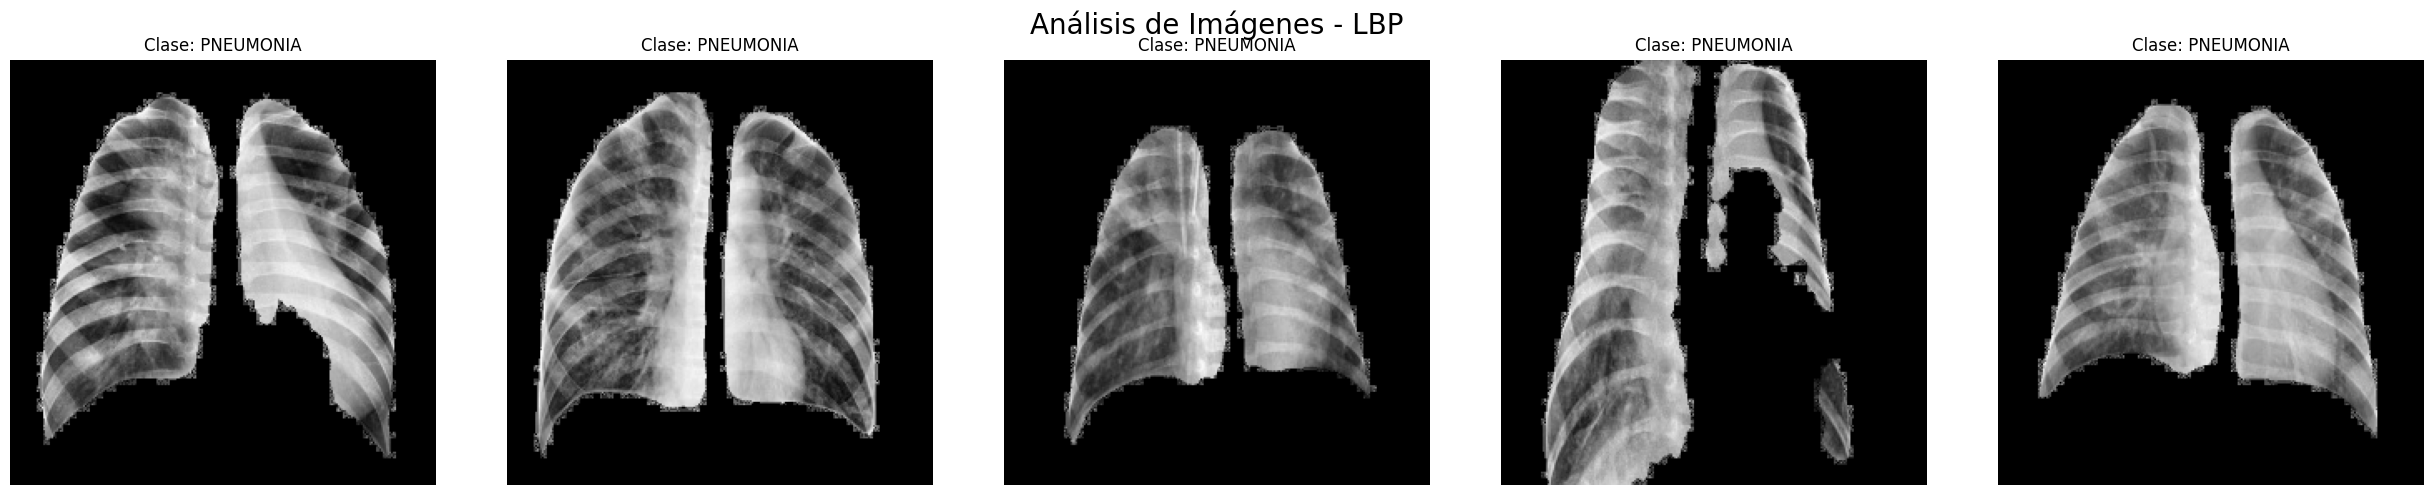

✔ Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_train.npz
✔ Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_train.npz
✔ Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_test.npz
✔ Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_test.npz
✔ Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_val.npz
✔ Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_val.npz


In [ ]:
# Definifición de parámetros de LBP

lbp_settings = [(8,1), (16,2), (24,3)]

from skimage.feature import local_binary_pattern

# Definición de la función para obtener histograma LBP para diferentes número de puntos (P) y radios (R)

def get_lbp_features(img, lbp_settings):

    all_features = []

    for P, R in lbp_settings:
        lbp = local_binary_pattern(img, P, R, method="uniform")

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, P + 3),
            range=(0, P + 2),
            density=True
        )

        all_features.append(hist.astype(np.float32))

    return np.concatenate(all_features, axis=0)

# Visualización de imágenes y features LBP

def analize_random_lbp(image_list, label, lbp_settings, img_num=5):

    if len(image_list) == 0:
        print(f"No hay imágenes para la clase '{label}'.")
        return

    imgs_random = random.sample(image_list, min(img_num, len(image_list)))
    fig, ax = plt.subplots(1, len(imgs_random), figsize=(25, 5))

    if len(imgs_random) == 1:
        ax = [ax]

    for i, img_path in enumerate(imgs_random):

        # cargar y preprocesar

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))

        features = get_lbp_features(img, lbp_settings)

        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(f"Clase: {label}")
        ax[i].axis("off")

        print(f"\nImagen: {img_path}")
        print(f"Dimensión total del vector LBP: {features.shape[0]}")

        # Mostrar los histogramas separadamente por configuración (P,R)

        start = 0
        for P, R in lbp_settings:
            bins = P + 2
            end = start + bins
            hist = features[start:end]
            start = end

            print(f"  LBP(P={P}, R={R}):")
            print(f"    Histograma: {hist}")

    fig.suptitle("Análisis de Imágenes - LBP", fontsize=20)
    plt.tight_layout()
    plt.show()

# Gnerar dataset LBP y guardarlo como NPZ

def dataset_npz_lbp_fast(image_list, label, lbp_settings, salida_npz):

    X_list = []
    y_list = []
    files_list = []

    for img_path in image_list:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))

        features = get_lbp_features(img, lbp_settings)

        X_list.append(features)
        y_list.append(label)
        files_list.append(os.path.basename(img_path))

    features_array = np.array(X_list, dtype=np.float32)
    labels_array = np.array(y_list)
    filenames_array = np.array(files_list)

    # Ensure the directory exists before saving the file
    os.makedirs(os.path.dirname(salida_npz), exist_ok=True)

    np.savez(salida_npz, features=features_array,
             labels=labels_array, filenames=filenames_array)

    print(f"✔ Archivo .npz generado correctamente: {salida_npz}")


# Visualización aleatoria para cada clase
analize_random_lbp(train_normal, "NORMAL", lbp_settings)
analize_random_lbp(train_pneu, "PNEUMONIA", lbp_settings)

# RUTAS DE SALIDA
save_path_normal = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_train.npz"
save_path_pneu   = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_train.npz"

save_path_normal_test = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_test.npz"
save_path_pneu_test   = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_test.npz"

save_path_normal_val = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_val.npz"
save_path_pneu_val   = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_val.npz"

# GENERAR FEATURES PARA CADA SPLIT

dataset_npz_lbp_fast(train_normal, "NORMAL", lbp_settings, save_path_normal)
dataset_npz_lbp_fast(train_pneu, "PNEUMONIA", lbp_settings, save_path_pneu)

dataset_npz_lbp_fast(test_normal, "NORMAL", lbp_settings, save_path_normal_test)
dataset_npz_lbp_fast(test_pneu, "PNEUMONIA", lbp_settings, save_path_pneu_test)

dataset_npz_lbp_fast(val_normal, "NORMAL", lbp_settings, save_path_normal_val)
dataset_npz_lbp_fast(val_pneu, "PNEUMONIA", lbp_settings, save_path_pneu_val)

# 2.2. Descriptor de textura GLCM


Imagen seleccionada: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped/train/NORMAL/IM-0622-0001-0001.jpeg
Dist=1 ang=0.00 -> Contraste: 1.38, Correlación: 0.96, Energía: 0.63291, Homogeneidad: 0.86
Dist=1 ang=0.00 -> Contraste: 0.93, Correlación: 0.97, Energía: 0.63578, Homogeneidad: 0.87
Dist=1 ang=0.00 -> Contraste: 1.72, Correlación: 0.94, Energía: 0.62879, Homogeneidad: 0.84
Dist=1 ang=0.00 -> Contraste: 1.76, Correlación: 0.94, Energía: 0.62890, Homogeneidad: 0.84
Dist=1 ang=0.00 -> Contraste: 2.85, Correlación: 0.91, Energía: 0.62461, Homogeneidad: 0.81
Dist=1 ang=0.00 -> Contraste: 1.83, Correlación: 0.94, Energía: 0.63046, Homogeneidad: 0.82
Dist=1 ang=0.00 -> Contraste: 1.72, Correlación: 0.94, Energía: 0.62879, Homogeneidad: 0.84
Dist=1 ang=0.00 -> Contraste: 1.76, Correlación: 0.94, Energía: 0.62890, Homogeneidad: 0.84
Dist=1 ang=0.00 -> Contraste: 5.99, Correlación: 0.81, Energía: 0.60922, Homogeneidad: 0.75
Dist=1 ang=0.00 -

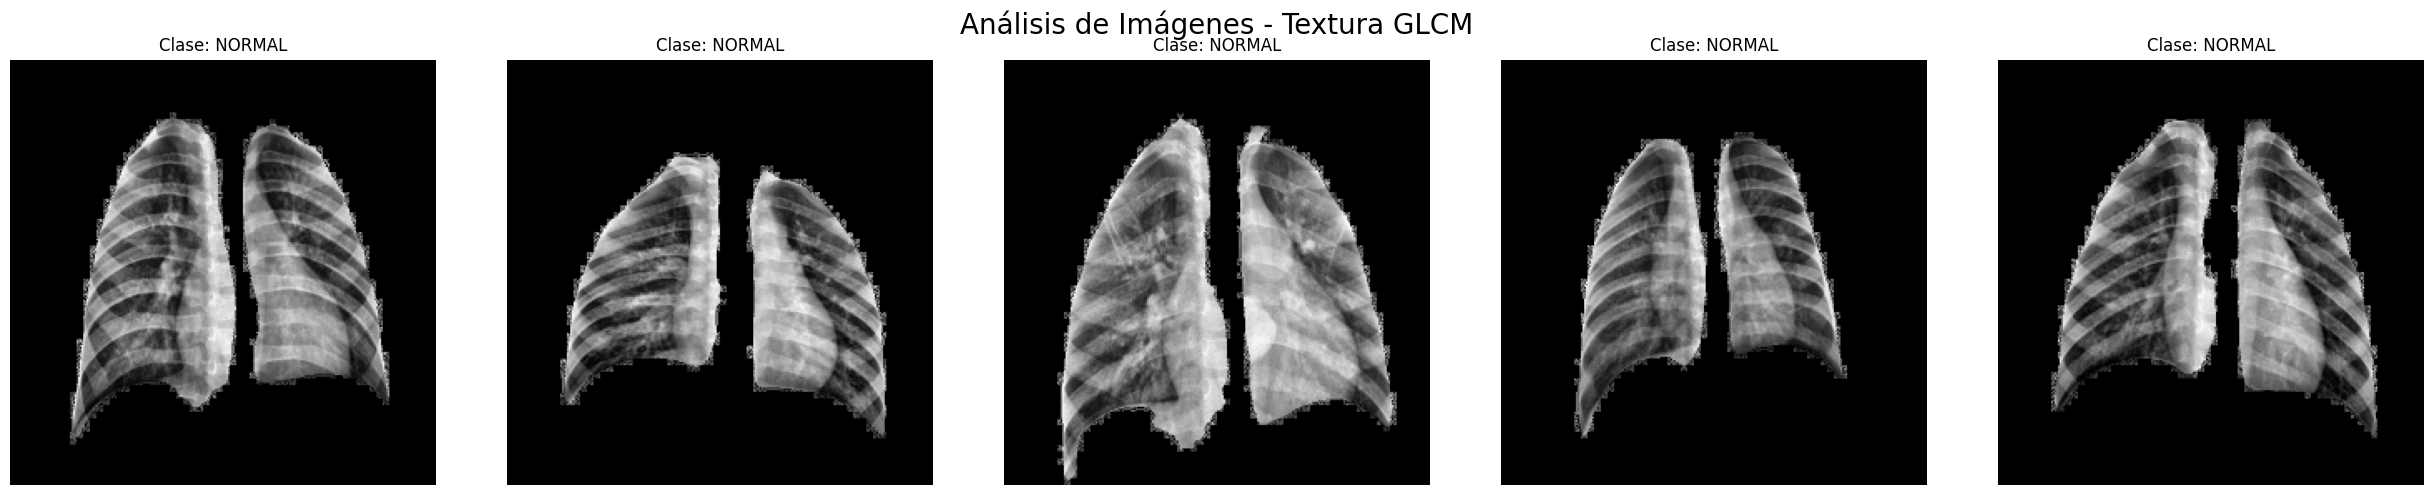


Imagen seleccionada: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped/train/PNEUMONIA/person441_bacteria_1917.jpeg
Dist=1 ang=0.00 -> Contraste: 0.84, Correlación: 0.97, Energía: 0.62436, Homogeneidad: 0.90
Dist=1 ang=0.00 -> Contraste: 0.52, Correlación: 0.98, Energía: 0.62753, Homogeneidad: 0.91
Dist=1 ang=0.00 -> Contraste: 1.06, Correlación: 0.96, Energía: 0.61962, Homogeneidad: 0.88
Dist=1 ang=0.00 -> Contraste: 0.97, Correlación: 0.97, Energía: 0.61988, Homogeneidad: 0.88
Dist=1 ang=0.00 -> Contraste: 1.69, Correlación: 0.94, Energía: 0.61498, Homogeneidad: 0.86
Dist=1 ang=0.00 -> Contraste: 0.97, Correlación: 0.97, Energía: 0.62117, Homogeneidad: 0.87
Dist=1 ang=0.00 -> Contraste: 1.06, Correlación: 0.96, Energía: 0.61962, Homogeneidad: 0.88
Dist=1 ang=0.00 -> Contraste: 0.97, Correlación: 0.97, Energía: 0.61988, Homogeneidad: 0.88
Dist=1 ang=0.00 -> Contraste: 3.59, Correlación: 0.88, Energía: 0.59804, Homogeneidad: 0.80
Dist=1 a

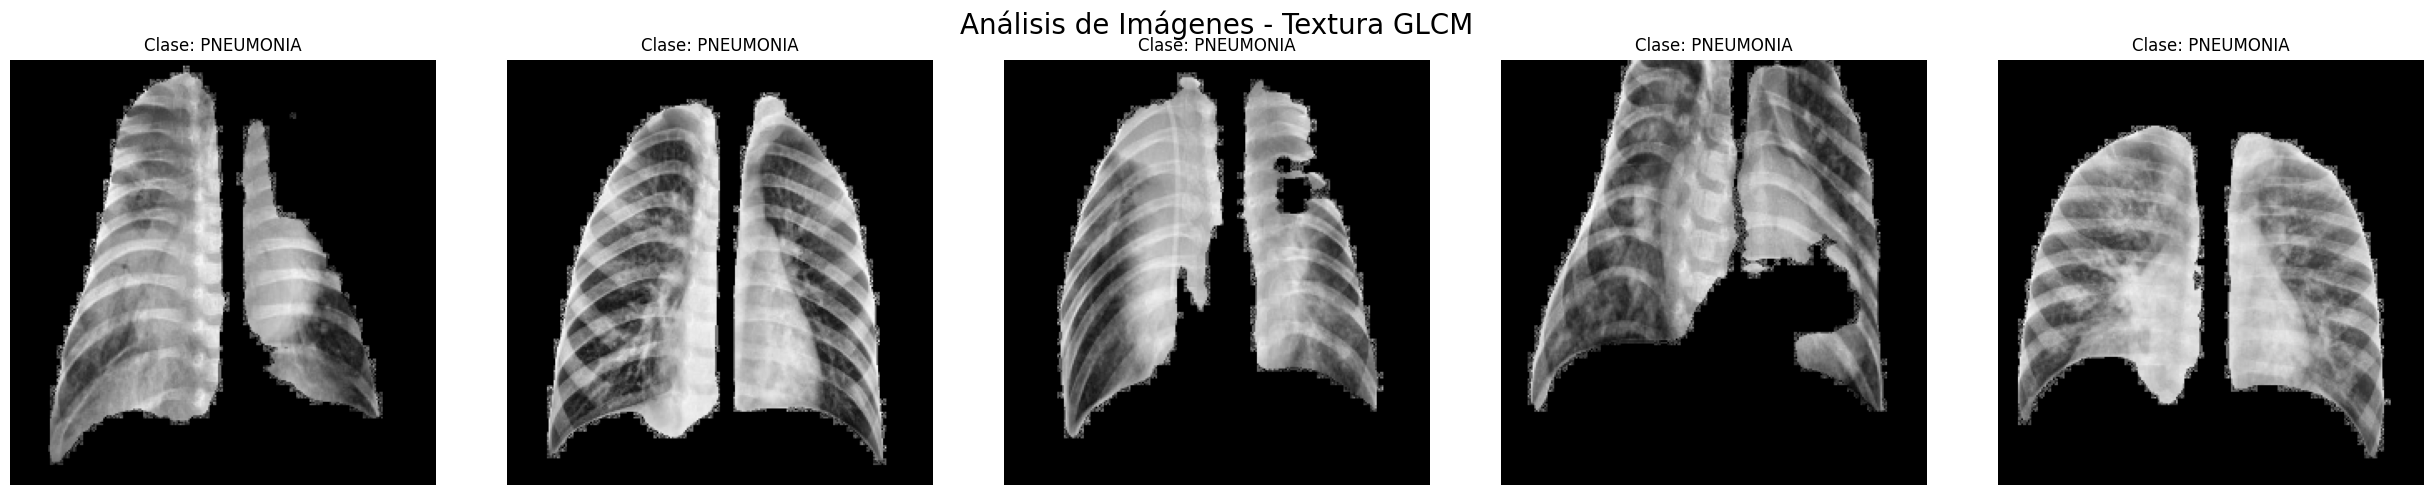

Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_train.npz
Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_train.npz
Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/glcm_normal_test.npz
Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/glcm_pneu_test.npz
Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/glcm_normal_val.npz
Archivo .npz generado correctamente: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/glcm_pneu_val.npz


In [ ]:
distances = [1, 2, 4]
angles = [0, np.pi/2, np.pi/4, 3*np.pi/4]
levels = 16

def get_glcm_features(img, distances, angles, levels=16):
    img_small = (img // (256 // levels)).astype(np.uint8)
    resultados = []
    for d in distances:
        glcm = graycomatrix(img_small,
                            distances=[d],
                            angles=angles,
                            levels=levels,
                            symmetric=True,
                            normed=True)
        for idx, angle in enumerate(angles):
            resultados.append([
                graycoprops(glcm, 'contrast')[0, idx],
                graycoprops(glcm, 'correlation')[0, idx],
                graycoprops(glcm, 'energy')[0, idx],
                graycoprops(glcm, 'homogeneity')[0, idx]
            ])
    return np.array(resultados, dtype=np.float32)

def analize_random_glcm(image_list, label, distances, angles, img_num=5):
    if len(image_list) == 0:
        print(f"No hay imágenes para la clase '{label}'.")
        return

    imgs_random = random.sample(image_list, min(img_num, len(image_list)))
    fig, ax = plt.subplots(1, len(imgs_random), figsize=(25, 5))
    if len(imgs_random) == 1:
        ax = [ax]

    for i, img_path in enumerate(imgs_random):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        features = get_glcm_features(img, distances, angles, levels)

        ax[i].imshow(img, cmap='gray')
        ax[i].set_title(f"Clase: {label}")
        ax[i].axis("off")

        print(f"\nImagen seleccionada: {img_path}")
        for f in features:
            print(
                f"Dist={distances[0]} ang={angles[0]:.2f} -> "
                f"Contraste: {f[0]:.2f}, "
                f"Correlación: {f[1]:.2f}, "
                f"Energía: {f[2]:.5f}, "
                f"Homogeneidad: {f[3]:.2f}"
            )

    fig.suptitle("Análisis de Imágenes - Textura GLCM", fontsize=20)
    plt.tight_layout()
    plt.show()

def dataset_npz_fast(image_list, label, distances, angles, salida_npz):
    X_list = []
    y_list = []
    files_list = []

    for img_path in image_list:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        features = get_glcm_features(img, distances, angles, levels)
        X_list.append(features.flatten())
        y_list.append(label)
        files_list.append(os.path.basename(img_path))

    features_array = np.array(X_list, dtype=np.float32)
    labels_array = np.array(y_list)
    filenames_array = np.array(files_list)

    np.savez(salida_npz, features=features_array, labels=labels_array, filenames=filenames_array)
    print(f"Archivo .npz generado correctamente: {salida_npz}")

analize_random_glcm(train_normal, "NORMAL", distances, angles)
analize_random_glcm(train_pneu, "PNEUMONIA", distances, angles)

save_path_normal = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_train.npz"
save_path_pneu   = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_train.npz"

save_path_normal_test = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_test.npz"
save_path_pneu_test   = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_test.npz"

save_path_normal_val = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_val.npz"
save_path_pneu_val = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_val.npz"

dataset_npz_fast(train_normal, "NORMAL", distances, angles, save_path_normal)
dataset_npz_fast(train_pneu, "PNEUMONIA", distances, angles, save_path_pneu)

dataset_npz_fast(test_normal, "NORMAL", distances, angles, save_path_normal_test)
dataset_npz_fast(test_pneu, "PNEUMONIA", distances, angles, save_path_pneu_test)

dataset_npz_fast(val_normal, "NORMAL", distances, angles, save_path_normal_val)
dataset_npz_fast(val_pneu, "PNEUMONIA", distances, angles, save_path_pneu_val)




## 2.3 Filtros de Gabor
+Banco de filtros con diferentes frecuencias y orientaciones

+Estadísticas de respuesta (media, desviación estándar)

In [ ]:
#Ruta del dataset
DATASET_PATH_CROP = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped"
train_normal_crop = glob(os.path.join(DATASET_PATH_CROP, "train/NORMAL/*.jpeg"))
train_pneu_crop   = glob(os.path.join(DATASET_PATH_CROP, "train/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal_crop))
print("PNEUMONIA train:", len(train_pneu_crop))

NORMAL train: 1341
PNEUMONIA train: 3875


In [ ]:
#Ruta de salida

FEATURES_PATH = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features"

os.makedirs(FEATURES_PATH, exist_ok=True)

subsets = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]
label_map = {"NORMAL": 0, "PNEUMONIA": 1}

In [ ]:
#Se define la función para construir los kernel para los filtros
def build_gabor_kernels(scales=[4, 8, 16], orientations=4, ksize=31):
    """
    scales: lista de longitudes de onda (λ)
    orientations: número de orientaciones (por ejemplo 4 → 0,45,90,135°)
    ksize: tamaño del kernel (cuadrado)
    """
    kernels = []
    for lam in scales:
        for i in range(orientations):
            theta = i * np.pi / orientations  # 0, pi/4, pi/2, 3pi/4...

            # Parámetros típicos Gabor
            sigma = 0.56 * lam      # relación común sigma-λ
            gamma = 0.5             # relación de aspecto
            psi   = 0               # fase

            k = cv2.getGaborKernel(
                (ksize, ksize),
                sigma=sigma,
                theta=theta,
                lambd=lam,
                gamma=gamma,
                psi=psi,
                ktype=cv2.CV_32F
            )
            kernels.append(((lam, theta), k))
    return kernels


#Se define la función para extraer las carcterísticas

def gabor_features(image, kernels):
    """
    image: imagen en escala de grises (pulmón recortado, np.uint8 o float)
    kernels: lista de ((λ, θ), kernel) como la que devuelve build_gabor_kernels
    return: vector de características concatenando [mean, std] de cada respuesta
    """
    feats = []

    # Asegurar float
    img = image.astype(np.float32)

    for (lam, theta), k in kernels:
        # Convolución
        filtered = cv2.filter2D(img, cv2.CV_32F, k)

        # Estadísticos simples (puedes añadir más: energía, skewness, etc.)
        mean_val = filtered.mean()
        std_val  = filtered.std()

        feats.extend([mean_val, std_val])

    return np.array(feats, dtype=np.float32)

In [ ]:
# 1. Construir banco de Gabor multi–escala
kernels = build_gabor_kernels(scales=[4, 8, 16], orientations=4, ksize=31)

Dimensión del vector Gabor: (24,)
Primeros valores:
 [  5.7930746 137.40703     5.7962027  62.66506     5.793075   67.83786
   5.7962027  60.15702    17.40321   568.6875   ]


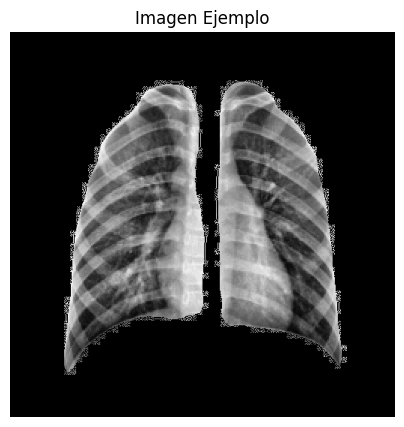

In [ ]:
#Ejemplo con una de las imágenes

img_gabor=cv2.imread(train_normal_crop[0], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img_gabor, cmap='gray')
plt.title("Imagen Ejemplo")
plt.axis("off")

gabor_feats = gabor_features(img_gabor, kernels)
print("Dimensión del vector Gabor:", gabor_feats.shape)
print("Primeros valores:\n", gabor_feats[:10])

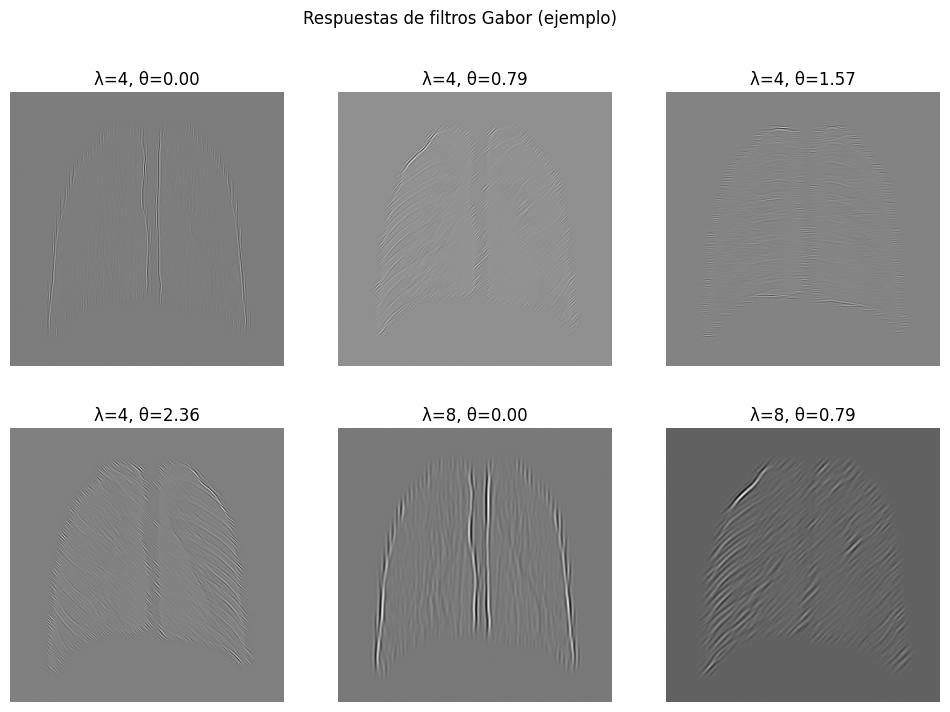

In [ ]:
# Tomar los primeros 6 filtros como ejemplo
show_kernels = kernels[:6]

fig=plt.figure(figsize=(12,8))

for i, ((lam, theta), k) in enumerate(show_kernels):
    filtered = cv2.filter2D(img_gabor.astype(np.float32), cv2.CV_32F, k)

    plt.subplot(2, 3, i+1)
    plt.imshow(filtered, cmap='gray')
    plt.title(f"λ={lam}, θ={theta:.2f}")
    plt.axis("off")

plt.suptitle("Respuestas de filtros Gabor")
plt.show()
ruta_guardado = os.path.join("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/imagenes", "comparacionGabor.png")
fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
plt.close(fig)


In [ ]:
#Se genera para todo el dataset

for subset in subsets:
    X_list = []
    y_list = []
    files_list = []

    print(f"\n=== Procesando Gabor multi–escala: {subset} ===")

    for cls in classes:
        img_dir = os.path.join(DATASET_PATH_CROP, subset, cls)
        img_paths = glob(os.path.join(img_dir, "*.jpeg"))

        print(f"{subset}/{cls}: {len(img_paths)} imágenes")

        for p in tqdm(img_paths, desc=f"{subset}/{cls}"):
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print("Error leyendo:", p)
                continue

            feats = gabor_features(img, kernels)
            X_list.append(feats)
            y_list.append(label_map[cls])
            files_list.append(p)

    # Convertir a arrays
    X = np.vstack(X_list)        # (N, 48)
    y = np.array(y_list)         # (N,)
    files = np.array(files_list) # (N,)

    print(f"{subset}: X shape = {X.shape}, y shape = {y.shape}")

    # Guardar
    out_path = os.path.join(FEATURES_PATH, f"gabor_{subset}.npz")
    np.savez(out_path, X=X, y=y, files=files)

    print("Guardado:", out_path)


=== Procesando Gabor multi–escala: train ===
train/NORMAL: 1341 imágenes


train/NORMAL: 100%|██████████| 1341/1341 [06:33<00:00,  3.41it/s]


train/PNEUMONIA: 3875 imágenes


train/PNEUMONIA: 100%|██████████| 3875/3875 [18:06<00:00,  3.57it/s]


train: X shape = (5216, 24), y shape = (5216,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_train.npz

=== Procesando Gabor multi–escala: val ===
val/NORMAL: 8 imágenes


...

val: X shape = (16, 24), y shape = (16,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_val.npz

=== Procesando Gabor multi–escala: test ===
test/NORMAL: 234 imágenes


test/NORMAL: 100%|██████████| 234/234 [01:03<00:00,  3.66it/s]


test/PNEUMONIA: 390 imágenes


test/PNEUMONIA: 100%|██████████| 390/390 [01:48<00:00,  3.61it/s]

test: X shape = (624, 24), y shape = (624,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_test.npz
